In [2]:
import time
import pandas as pd
import json
import numpy as np
from datetime import datetime
from datetime import timezone
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.colors import ListedColormap
import numpy as np
# import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [3]:
def remove_specific_cycles(data_loader, indices_to_remove):
    """
    Excludes specific indices from every key in the dataset.
    indices_to_remove: list of integers (e.g., [1, 3, 6])
    """
    cleaned_data = {}
    
    for key in data_loader.files:
        original_list = list(data_loader[key])
        # Keep only the items whose index is NOT in our 'remove' list
        cleaned_data[key] = [
            cycle for i, cycle in enumerate(original_list) 
            if i not in indices_to_remove
        ]
        
    return cleaned_data

def get_cycle_stats(data_source, param_prefix, leg, norm_points=100):
    """
    Interpolates cycles for a specific leg/parameter and calculates mean/std.
    """
    key = f'{param_prefix}_{leg}'
    if key not in data_source:
        return None, None, None

    raw_cycles = data_source[key]
    normalized_list = []
    

    for j, cycle in enumerate(raw_cycles):
            
        x_old = np.linspace(0, 100, len(cycle))
        x_new = np.linspace(0, 100, norm_points)
        norm_cycle = np.interp(x_new, x_old, cycle)
        normalized_list.append(norm_cycle)
    
    if not normalized_list:
        return None, None, None

    norm_matrix = np.array(normalized_list)
    mean_vals = np.mean(norm_matrix, axis=0)
    std_vals = np.std(norm_matrix, axis=0)
    x_axis = np.linspace(0, 100, norm_points)

    return x_axis, mean_vals, std_vals

In [4]:
def load_cycles_from_npz(filename):
    """
    Loads a flattened .npz file and reconstructs the nested dictionary.
    """
    data = np.load(filename)
    reconstructed = {}
    
    for key in data.files:
        # Split the key (e.g., 'rough_foot_force')
        # We use rsplit once from the right to handle sensor names with underscores
        parts = key.split('_', 1) 
        if len(parts) < 2: continue
        
        terrain, sensor = parts[0], parts[1]
        
        if terrain not in reconstructed:
            reconstructed[terrain] = {}
        
        # Convert the (N, 100, F) array back into a list of (100, F) arrays
        # This makes it compatible with your existing segment_all_trials output
        reconstructed[terrain][sensor] = [cycle for cycle in data[key]]
        
    print(f"Loaded {len(reconstructed)} terrains from {filename}")
    return reconstructed

# --- Execution ---
dataset = load_cycles_from_npz('walking_terrain_datasets.npz')

Loaded 3 terrains from walking_terrain_datasets.npz


In [5]:
name_joints = ['FR_J1', 'FR_J2', 'FR_J3', 'FR_J4', 
 'BR_J1', 'BR_J2', 'BR_J3', 'BR_J4', 
 'FL_J1', 'FL_J2', 'FL_J3', 'FL_J4', 
 'BL_J1', 'BL_J2', 'BL_J3', 'BL_J4']

name_legs = ['FR', 'BR', 'FL', 'BL']

# Plot show

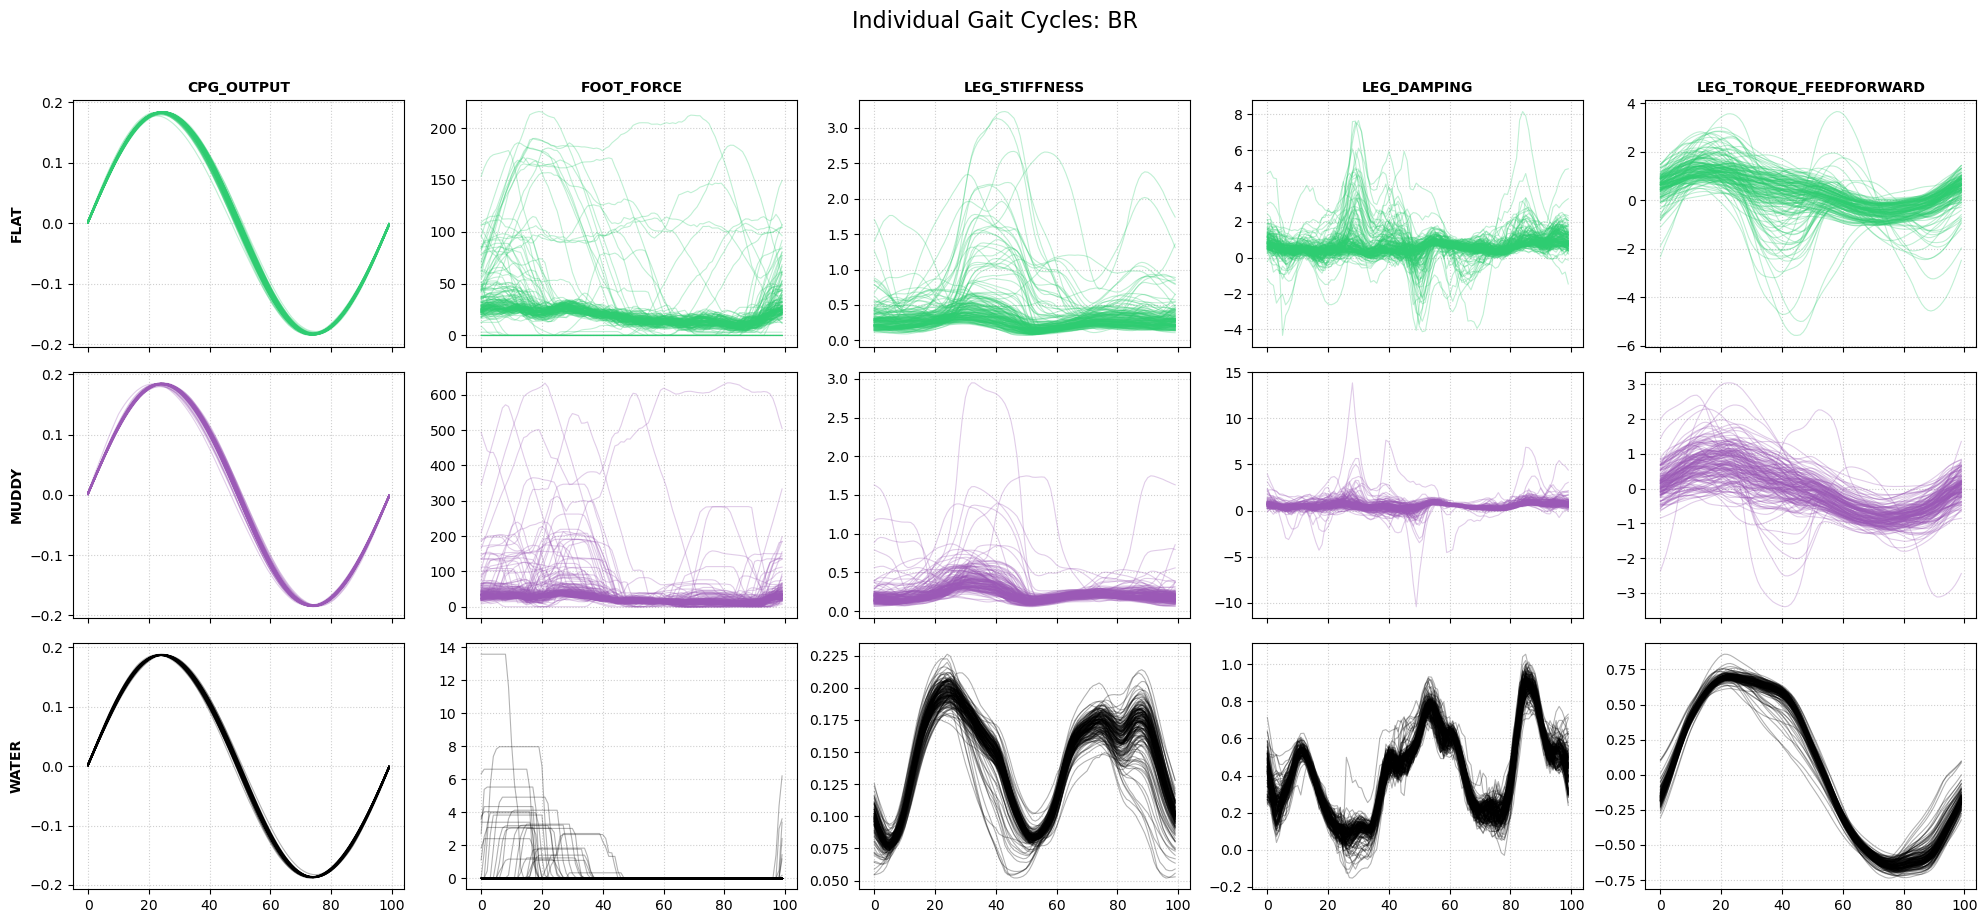

In [6]:
def plot_all_individual_cycles(cycle_results, sensor_list, feature_idx=0):
    """
    Plots every single cycle for every terrain to see the raw distribution.
    """
    terrains = list(cycle_results.keys())
    num_terrains = len(terrains)
    num_sensors = len(sensor_list)
    
    colors = {
        'flat': '#2ecc71', 'rough': '#e74c3c', 'sponge': '#3498db', 
        'sandy': '#f1c40f', 'muddy': '#9b59b6'
    }

    # Use a dynamic title based on the index
    # We try to find the name from the global scope, otherwise use the index number
    try:
        # Check if the first sensor in the list is a leg or joint sensor
        is_joint = 'joint' in sensor_list[0]
        feature_name = name_joints[feature_idx] if is_joint else name_legs[feature_idx]
    except (NameError, IndexError):
        feature_name = f"Index {feature_idx}"

    fig, axes = plt.subplots(num_terrains, num_sensors, 
                               figsize=(4 * num_sensors, 3 * num_terrains), 
                               sharex=True, squeeze=False) # squeeze=False keeps axes 2D (rows, cols)

    for t_idx, terrain in enumerate(terrains):
        for s_idx, sensor in enumerate(sensor_list):
            ax = axes[t_idx, s_idx]
            
            # Use .get() to avoid KeyError if a sensor is missing for a terrain
            cycles = cycle_results.get(terrain, {}).get(sensor, [])
            
            if not cycles or len(cycles) == 0:
                ax.text(0.5, 0.5, 'No Data', ha='center', transform=ax.transAxes)
                continue
            
            color = colors.get(terrain, 'black')
            
            # Plot every single cycle
            for cycle in cycles:
                # cycle shape is (100, num_features)
                ax.plot(cycle[:, feature_idx], color=color, alpha=0.3, linewidth=0.8)
            
            # Formatting titles only for the top row
            if t_idx == 0:
                ax.set_title(f"{sensor.upper()}", fontsize=10, fontweight='bold')
            
            # Formatting labels only for the first column
            if s_idx == 0:
                ax.set_ylabel(f"{terrain.upper()}", fontsize=10, fontweight='bold')
            
            ax.grid(True, linestyle=':', alpha=0.6)

    plt.suptitle(f"Individual Gait Cycles: {feature_name}", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# --- Execution ---
sensors_to_plot = ['cpg_output', 'foot_force', 'leg_stiffness', 'leg_damping', 'leg_torque_feedforward']
plot_all_individual_cycles(dataset, sensors_to_plot, feature_idx=1)

In [7]:

def plot_all_sensors_comparison(cycle_results, sensor_list, feature_index=0, feature_name="Leg 0"):
    """
    Creates a vertical stack of subplots comparing multiple sensors across all terrains.
    """
    terrains = list(cycle_results.keys())
    colors = {'flat': 'green', 'rough': 'red', 'water': 'blue', 'sandy': 'orange', 'muddy': 'brown'}
    
    num_sensors = len(sensor_list)
    fig, axes = plt.subplots(num_sensors, 1, figsize=(5, 3 * num_sensors), sharex=True)
    
    # Ensure axes is iterable even if there's only one sensor
    if num_sensors == 1:
        axes = [axes]

    for i, sensor_name in enumerate(sensor_list):
        ax = axes[i]
        
        for terrain in terrains:
            # Check if data exists for this terrain/sensor combo
            cycles = cycle_results.get(terrain, {}).get(sensor_name, [])
            if not cycles:
                continue
                
            data_stack = np.stack(cycles)
            feature_data = data_stack[:, :, feature_index]
            
            mean_traj = np.mean(feature_data, axis=0)
            std_traj = np.std(feature_data, axis=0)
            
            x = np.arange(100)
            color = colors.get(terrain, 'black')
            
            ax.plot(x, mean_traj, label=terrain.capitalize(), color=color, linewidth=2)
            ax.fill_between(x, mean_traj - std_traj, mean_traj + std_traj, color=color, alpha=0.1)

        ax.set_ylabel("Value")
        ax.set_title(f"{sensor_name.replace('_', ' ').upper()}", fontsize=12, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.6)
        
        # Only put the legend on the top plot to keep it clean
        if i == 0:
            ax.legend(loc='upper right', ncol=2, fontsize='small')

    plt.xlabel("Gait Cycle (%)")
    plt.suptitle(f"Comparison Across Terrains - {feature_name}", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.savefig("terrain_comparison.png", dpi=300, bbox_inches='tight')
    plt.show()

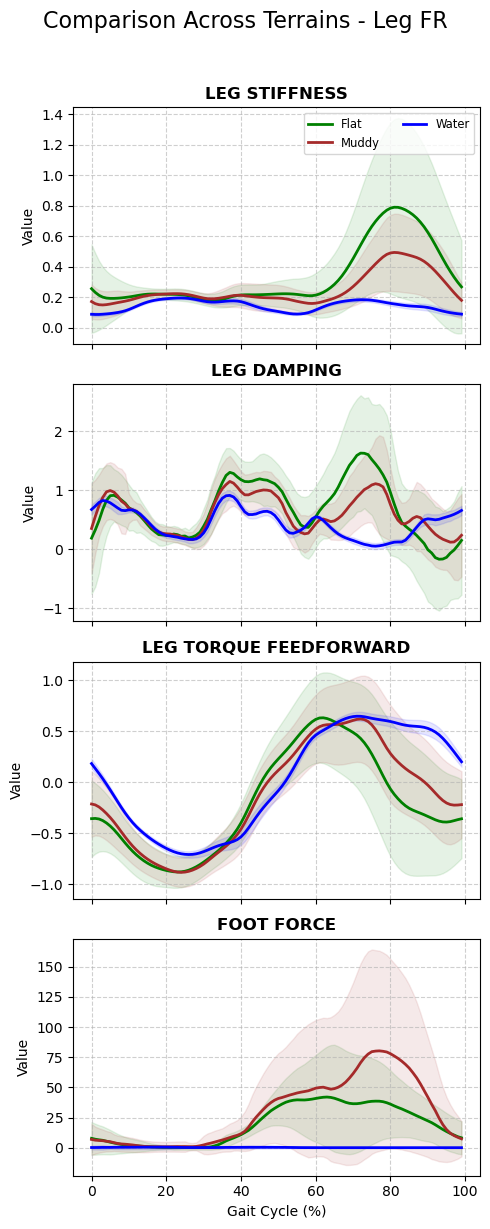

In [8]:
# List the sensors you want to visualize from the loaded file
sensors_to_plot = [
    'leg_stiffness', 
    'leg_damping', 
    'leg_torque_feedforward', 
    'foot_force'
]

# Use your previous subplot function
# Ensure name_legs is defined in your current environment
plot_all_sensors_comparison(
    dataset, 
    sensors_to_plot, 
    feature_index=0, 
    feature_name=f"Leg {name_legs[0]}"
)

# Train Process

In [9]:
dataset['flat']['foot_force']

[array([[1.91134432e+00, 2.74442280e+01, 7.31047071e+01, 1.03361051e+01,
         3.56066200e+00],
        [1.25945566e+00, 2.81056268e+01, 8.22028663e+01, 1.03361051e+01,
         3.58209293e+00],
        [1.25945566e+00, 2.86172274e+01, 9.15577606e+01, 1.03361051e+01,
         3.59943143e+00],
        [1.25945566e+00, 2.92476336e+01, 1.01103151e+02, 1.27064218e+01,
         3.61747079e+00],
        [6.69318958e-01, 2.80085860e+01, 1.10377243e+02, 1.55076457e+01,
         3.63906979e+00],
        [3.09413993e-02, 2.61684711e+01, 1.19696434e+02, 1.73918283e+01,
         3.65496324e+00],
        [0.00000000e+00, 2.63437649e+01, 1.27724326e+02, 1.94311104e+01,
         3.67354345e+00],
        [0.00000000e+00, 2.69855891e+01, 1.33762641e+02, 2.02548437e+01,
         3.68961243e+00],
        [0.00000000e+00, 2.37658566e+01, 1.38907134e+02, 1.98573642e+01,
         3.71030007e+00],
        [0.00000000e+00, 2.06205884e+01, 1.47485578e+02, 1.93945033e+01,
         3.72621145e+00],
        [0

In [10]:
import numpy as np
import random

def split_gait_dataset(dataset, train_ratio=0.8, seed=42):
    """
    Splits the gait cycle dataset into training and testing sets.
    Safely handles sensors with mismatched cycle counts.
    """
    random.seed(seed)
    train_set = {}
    test_set = {}

    for terrain in dataset.keys():
        # 1. FIND THE MINIMUM CYCLE COUNT ACROSS ALL SENSORS
        # This ensures we don't try to access an index that doesn't exist for a sensor
        sensor_counts = [len(dataset[terrain][s]) for s in dataset[terrain].keys()]
        if not sensor_counts:
            continue
            
        min_cycles = min(sensor_counts)
        
        # 2. Generate indices based on the shortest sensor stream
        indices = list(range(min_cycles))
        random.shuffle(indices)
        
        split_idx = int(min_cycles * train_ratio)
        train_indices = indices[:split_idx]
        test_indices = indices[split_idx:]
        
        train_set[terrain] = {}
        test_set[terrain] = {}

        # 3. Distribute cycles
        for sensor in dataset[terrain].keys():
            all_cycles = dataset[terrain][sensor]
            # We only take the cycles up to min_cycles to stay synchronized
            train_set[terrain][sensor] = [all_cycles[i] for i in train_indices]
            test_set[terrain][sensor] = [all_cycles[i] for i in test_indices]
            
        print(f"Terrain {terrain.upper()}: Used {min_cycles} synchronized cycles. "
              f"({len(train_indices)} train, {len(test_indices)} test)")

    return train_set, test_set

# --- Execution ---
train_data, test_data = split_gait_dataset(dataset, train_ratio=0.3)

Terrain FLAT: Used 62 synchronized cycles. (18 train, 44 test)
Terrain MUDDY: Used 59 synchronized cycles. (17 train, 42 test)
Terrain WATER: Used 53 synchronized cycles. (15 train, 38 test)


In [21]:
import numpy as np

def format_for_esn_per_leg(dataset_dict, terrain_to_id_map, legs):
    """
    Splits the dataset into independent matrices for each leg using precise column slicing.
    """
    X_dict = {leg: [] for leg in legs}
    y_formatted = []
    
    # --- CRITICAL CONFIGURATION ---
    # Which column index (0, 1, 2, or 3) corresponds to which leg?
    # (Assuming column 4 is the timestamp, so we ignore it completely)
    leg_col_idx = {
        'FR': 0,
        'FL': 1, 
        'BR': 2, 
        'BL': 3  
    }
    
    sensor_keys = ['leg_stiffness', 'leg_damping', 'leg_torque_feedforward']

    for terrain, sensors_data in dataset_dict.items():
        if terrain not in terrain_to_id_map:
            continue
            
        label = terrain_to_id_map[terrain]
        n_cycles = len(sensors_data[sensor_keys[0]])
        
        for i in range(n_cycles):
            for leg in legs:
                cycle_columns = []
                
                # Extract the 3 physical properties for this specific leg
                for sensor_name in sensor_keys:
                    # Load the (100 timesteps, 5 columns) array
                    full_array = np.array(sensors_data[sensor_name][i])
                    
                    # Grab ONLY the single column for this specific leg
                    col_index = leg_col_idx[leg]
                    
                    # Slice and reshape from (100,) to (100, 1) so it stacks correctly
                    leg_feature_column = full_array[:, col_index].reshape(-1, 1)
                    
                    cycle_columns.append(leg_feature_column)
                
                # Stack horizontally: 1 K + 1 D + 1 Tau = 3 columns total
                leg_gait_matrix = np.hstack(cycle_columns)
                X_dict[leg].append(leg_gait_matrix)
            
            # Append the label once per cycle
            y_formatted.append(label)
            
    return X_dict, np.array(y_formatted)

In [ ]:
from env_pred import SupervisedESN

# --- 1. Mappings & Setup ---
TERRAIN_LABELS = {'flat': 0, 'muddy': 1, 'water': 2}
LEGS = ['FR', 'BR', 'FL', 'BL']
ALL_KEYS = list(dataset['flat'].keys()) 

print("Splitting dataset...")
train_data, test_data = split_gait_dataset(dataset, train_ratio=0.5, seed=42)

print("\nFormatting data for Per-Leg ESNs via array slicing...")
X_train_dict, y_train = format_for_esn_per_leg(train_data, TERRAIN_LABELS, LEGS)
X_test_dict, y_test = format_for_esn_per_leg(test_data, TERRAIN_LABELS, LEGS)

print(f"FR Leg Matrix Shape: {X_train_dict['FR'][0].shape}") # This should print (90, 12)

Splitting dataset...
Terrain FLAT: Used 62 synchronized cycles. (31 train, 31 test)
Terrain MUDDY: Used 59 synchronized cycles. (29 train, 30 test)
Terrain WATER: Used 53 synchronized cycles. (26 train, 27 test)

Formatting data for Per-Leg ESNs via array slicing...
FR Leg Matrix Shape: (100, 3)

Training ESN for Leg: FR
Processing 86 gait cycles through the reservoir...
Solving for Readout Weights using Ridge Regression...
ESN Training complete. Readout weight shape: (3, 100)
--> FR Accuracy: 85.23%
ESN parameters saved to esn_weights_FR.npz
Training ESN for Leg: BR
Processing 86 gait cycles through the reservoir...
Solving for Readout Weights using Ridge Regression...
ESN Training complete. Readout weight shape: (3, 100)
--> BR Accuracy: 78.41%
ESN parameters saved to esn_weights_BR.npz
Training ESN for Leg: FL
Processing 86 gait cycles through the reservoir...
Solving for Readout Weights using Ridge Regression...
ESN Training complete. Readout weight shape: (3, 100)
--> FL Accuracy:

In [23]:
import itertools
import numpy as np
from env_pred import SupervisedESN

# --- 1. Define the Hyperparameter Grid ---
print("\nSetting up Hyperparameter Grid Search...")

param_grid = {
    'n_reservoir': [50, 100, 300], # Kept smaller since inputs are only 3D now!
    'leak_rate': [0.1, 0.3, 0.5, 0.8],
    'spectral_radius': [0.8, 0.9, 0.95],
    'lambda_reg': [0.001, 0.01, 0.1]
}

keys = param_grid.keys()
combinations = list(itertools.product(*param_grid.values()))
print(f"Total combinations to test per leg: {len(combinations)}")

LEGS = ['FR', 'FL', 'BR', 'BL']

# --- 2. Run the Search for EACH Leg ---
for leg in LEGS:
    print("\n" + "="*50)
    print(f"🚀 STARTING GRID SEARCH FOR LEG: {leg} 🚀")
    print("="*50)
    
    # Extract the specific data for this leg
    X_train = X_train_dict[leg]
    X_test = X_test_dict[leg]
    
    best_accuracy = 0.0
    best_params = None
    best_model = None

    for i, values in enumerate(combinations):
        params = dict(zip(keys, values))
        
        # Initialize
        model = SupervisedESN(
            n_reservoir=params['n_reservoir'], 
            leak_rate=params['leak_rate'], 
            spectral_radius=params['spectral_radius'], 
            lambda_reg=params['lambda_reg']
        )
        
        # Train
        model.fit(X_train, y_train)
        
        # Evaluate
        correct = 0
        for j in range(len(X_test)):
            predicted_class, _ = model.predict(X_test[j])
            if predicted_class == y_test[j]:
                correct += 1
                
        accuracy = (correct / len(X_test)) * 100
        
        # Print progress (optional: you can comment this out if it clutters the terminal)
        print(f"[{i+1}/{len(combinations)}] res={params['n_reservoir']}, leak={params['leak_rate']} -> Acc: {accuracy:.2f}%")
        
        # Update best model
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_params = params
            best_model = model

    # --- 3. Report and Save the Best Model for this Leg ---
    print("\n" + "*"*40)
    print(f"🏆 BEST MODEL FOR {leg} 🏆")
    print(f"Accuracy: {best_accuracy:.2f}%")
    print("Parameters:")
    for k, v in best_params.items():
        print(f" - {k}: {v}")
    print("*"*40 + "\n")

    # Save the model specifically named for this leg
    filename = f"locomotion_esn_{leg}_best.npz"
    best_model.save_model(filename)


Setting up Hyperparameter Grid Search...
Total combinations to test per leg: 108

🚀 STARTING GRID SEARCH FOR LEG: FR 🚀
Processing 86 gait cycles through the reservoir...
Solving for Readout Weights using Ridge Regression...
ESN Training complete. Readout weight shape: (3, 50)
[1/108] res=50, leak=0.1 -> Acc: 84.09%
Processing 86 gait cycles through the reservoir...
Solving for Readout Weights using Ridge Regression...
ESN Training complete. Readout weight shape: (3, 50)
[2/108] res=50, leak=0.1 -> Acc: 81.82%
Processing 86 gait cycles through the reservoir...
Solving for Readout Weights using Ridge Regression...
ESN Training complete. Readout weight shape: (3, 50)
[3/108] res=50, leak=0.1 -> Acc: 70.45%
Processing 86 gait cycles through the reservoir...
Solving for Readout Weights using Ridge Regression...
ESN Training complete. Readout weight shape: (3, 50)
[4/108] res=50, leak=0.1 -> Acc: 87.50%
Processing 86 gait cycles through the reservoir...
Solving for Readout Weights using Rid

Booting up Per-Leg ESN Evaluator...

--- Evaluating FR Leg ---
ESN model loaded from env_pred_esn_FR_best.npz. (Classes: 3)
Test Accuracy: 90.91%

--- Evaluating FL Leg ---
ESN model loaded from env_pred_esn_FL_best.npz. (Classes: 3)
Test Accuracy: 94.32%

--- Evaluating BR Leg ---
ESN model loaded from env_pred_esn_BR_best.npz. (Classes: 3)
Test Accuracy: 94.32%

--- Evaluating BL Leg ---
ESN model loaded from env_pred_esn_BL_best.npz. (Classes: 3)
Test Accuracy: 82.95%



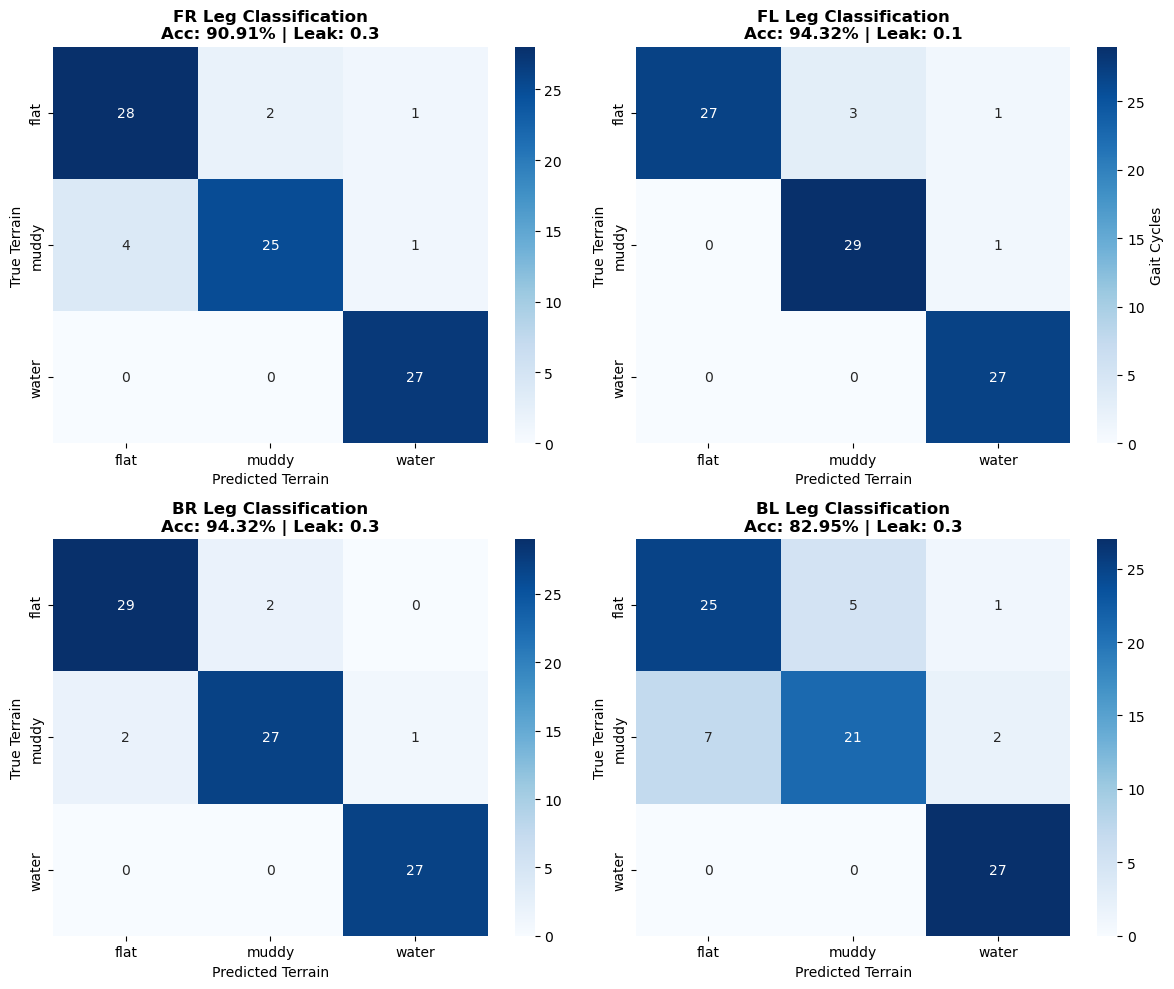

In [28]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from env_pred import SupervisedESN

# ==========================================
# 1. SETUP & MAPPINGS
# ==========================================
TERRAIN_LABELS = {'flat': 0, 'muddy': 1, 'water': 2}
terrain_names = [k for k, v in sorted(TERRAIN_LABELS.items(), key=lambda item: item[1])]
LEGS = ['FR', 'FL', 'BR', 'BL']

# Create a 2x2 grid for our 4 heatmaps
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# ==========================================
# 2. EVALUATE EACH LEG INDEPENDENTLY
# ==========================================
print("Booting up Per-Leg ESN Evaluator...\n")

for idx, leg in enumerate(LEGS):
    print(f"--- Evaluating {leg} Leg ---")
    
    # A. Load the specific model for this leg
    model = SupervisedESN()
    filename = f"env_pred_esn_{leg}_best.npz" 
    model.load_model(filename)
    
    # B. Get this leg's specific test data (from your format_for_esn_per_leg output)
    X_test_leg = X_test_dict[leg]
    
    # C. Run Predictions
    y_pred = []
    for i in range(len(X_test_leg)):
        predicted_class, confidence = model.predict(X_test_leg[i])
        y_pred.append(predicted_class)
        
    y_pred = np.array(y_pred)
    
    # D. Calculate Accuracy
    correct = np.sum(y_pred == y_test)
    accuracy = (correct / len(X_test_leg)) * 100
    print(f"Test Accuracy: {accuracy:.2f}%\n")
    
    # E. Plot Heatmap on the corresponding subplot
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=terrain_names, 
                yticklabels=terrain_names,
                ax=axes[idx],
                cbar_kws={'label': 'Gait Cycles'} if idx == 1 else None) # Only show colorbar once
    
    axes[idx].set_title(f'{leg} Leg Classification\nAcc: {accuracy:.2f}% | Leak: {model.leak_rate}', fontweight='bold')
    axes[idx].set_ylabel('True Terrain')
    axes[idx].set_xlabel('Predicted Terrain')

# Adjust layout and render
plt.tight_layout()
plt.show()